In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/datasets.zip -d /content/

Archive:  /content/drive/MyDrive/datasets.zip
   creating: /content/datasets/
   creating: /content/datasets/Planet Detection.v1i.yolov4pytorch/
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/README.dataset.txt  
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/README.roboflow.txt  
   creating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/download_jpg.rf.fa94d3530ab5a4fb27189be53f0bb984.jpg  
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/Earth-142-_jpg.rf.46a0e4218ceed77b0cea92be7e951c2f.jpg  
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/Earth-18-_jpg.rf.c4ff9ea2f4ef13b278e54e1a43ebb14e.jpg  
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/Earth-29-_jpg.rf.c6b59e871f308ceada3f7c24c1d20bd1.jpg  
  inflating: /content/datasets/Planet Detection.v1i.yolov4pytorch/test/Earth-3-_jpg.rf.d0b7762d5fe33

In [4]:
import os

print(os.path.exists("/content/datasets/Planet Detection.v1i.yolov4pytorch/train/_annotations.txt"))
print(os.path.exists("/content/datasets/Planet Detection.v1i.yolov4pytorch/train/_classes.txt"))

print(os.listdir("/content/datasets/Planet Detection.v1i.yolov4pytorch/train")[:5])


True
True
['Earth-146-_jpg.rf.8bec4f24afb561d3b998a8cc8bff5bc3.jpg', 'Venus-70-_jpg.rf.68bb2c8098c234429e288431f156f47a.jpg', 'Mars-20-_jpg.rf.ca995c8987be1c9aa32078aef06802b2.jpg', 'Jupiter-122-_jpg.rf.0c275fc7c364ac08838852397e4dfcc2.jpg', 'Jupiter-51-_jpg.rf.a7ebe85e1c7b93e34047e4236f7d15ef.jpg']


In [8]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T

# Use resized dataset
DATA_ROOT = r"/content/datasets/Planet_resized"

class PlanetDataset(Dataset):
    def __init__(self, split, ann_file, transform=None):
        self.transform = transform
        self.samples = []

        self.split_dir = os.path.join(DATA_ROOT, split)

        with open(ann_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                img_name = parts[0]

                bbox_data = parts[-1]
                class_id = int(bbox_data.split(",")[-1])

                img_path = os.path.join(self.split_dir, img_name)
                self.samples.append((img_path, class_id))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label


# Transforms (no resize needed because dataset is already 224x224)

transform_train = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])


# Correct split usage
train_ds = PlanetDataset(
    split="train",
    ann_file=r"/content/datasets/Planet Detection.v1i.yolov4pytorch/train/_annotations.txt",
    transform=transform_train
)

val_ds = PlanetDataset(
    split="valid",
    ann_file=r"/content/datasets/Planet Detection.v1i.yolov4pytorch/valid/_annotations.txt",
    transform=transform_val
)

test_ds = PlanetDataset(
    split="test",
    ann_file=r"/content/datasets/Planet Detection.v1i.yolov4pytorch/test/_annotations.txt",
    transform=transform_val
)

## EDA


Lets first see  if the all the images are alloted in the correct class and then we can move for a much more indepth EDA about the data


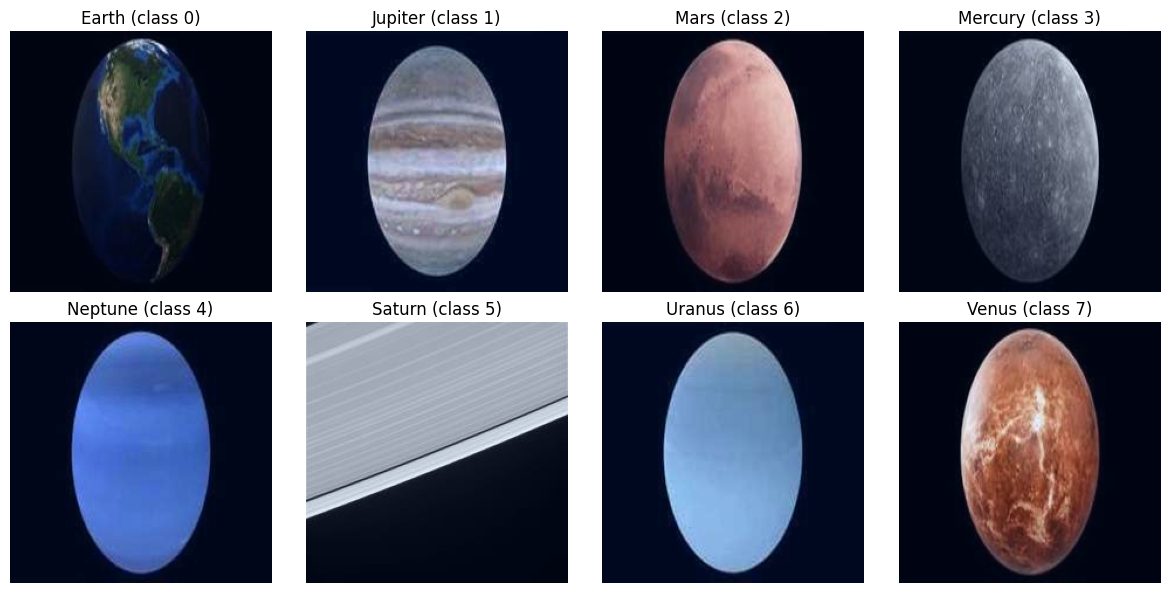

In [9]:
import matplotlib.pyplot as plt

samples_per_class = {}
id_to_name = {
    0: "Earth",
    1: "Jupiter",
    2: "Mars",
    3: "Mercury",
    4: "Neptune",
    5: "Saturn",
    6: "Uranus",
    7: "Venus"
}

for img, label in train_ds:

    if label not in samples_per_class:
        samples_per_class[label] = img

    if len(samples_per_class) == 8:
        break

plt.figure(figsize=(12, 6))
for i, (label, img) in enumerate(sorted(samples_per_class.items())):
    img_disp = img.permute(1, 2, 0).numpy()
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-8)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img_disp)
    plt.title(f"{id_to_name[label]} (class {label})")
    plt.axis("off")

plt.tight_layout()
plt.show()


Lets check the dataset for class imbalances and other possible biases and noises


Class distribution: Counter({5: 490, 1: 112, 2: 111, 0: 110, 4: 108, 3: 108, 6: 107, 7: 106})


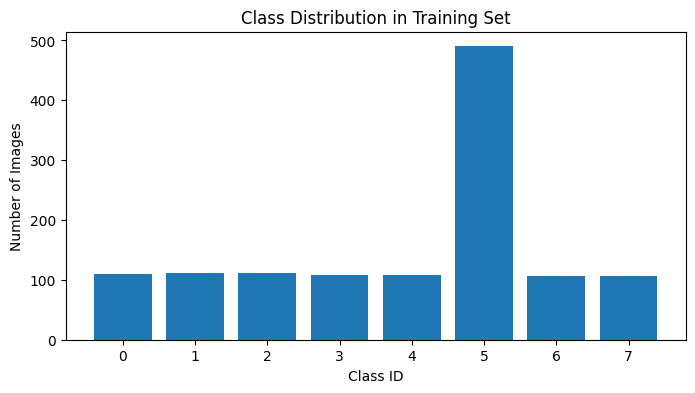

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

train_labels = [int(label) for _, label in train_ds]
counts = Counter(train_labels)

print("Class distribution:", counts)

plt.figure(figsize=(8,4))
plt.bar(counts.keys(), counts.values())
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set")
plt.show()


We can clearly observe that the dataset is clearly skewed towards seturn. What it means for our CNN down the line is, it can scream Saturn at every image and still have decent accuracy. So this needs to be dealt with rn I am thinking of adding weights to classes to make errors in minority classes more expensive


In [11]:
import torch
import numpy as np
import torchvision.transforms as T

# Temporarily remove normalization
transform_stats = T.Compose([
    T.ToTensor()
])

# Recreate dataset WITHOUT normalization
train_ds_stats = PlanetDataset(
    split="train",
    ann_file=r"/content/datasets/Planet Detection.v1i.yolov4pytorch/train/_annotations.txt",
    transform=transform_stats
)

num_samples = min(200, len(train_ds_stats))  # adjust if needed

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)

for i in range(num_samples):
    img, _ = train_ds_stats[i]  # img shape: (3, H, W)

    channel_sum += img.mean(dim=(1, 2))
    channel_squared_sum += (img ** 2).mean(dim=(1, 2))

# Mean
mean = channel_sum / num_samples

# Std
std = (channel_squared_sum / num_samples - mean ** 2) ** 0.5

print("Dataset Mean (R,G,B):", mean)
print("Dataset Std (R,G,B):", std)

Dataset Mean (R,G,B): tensor([0.2318, 0.2214, 0.2253])
Dataset Std (R,G,B): tensor([0.3026, 0.2886, 0.2894])


We can clearly see the all the images as RGB as expected and I am not showing the resolution because i already used transform to resize to 224*224 it doesnt  matter any now.


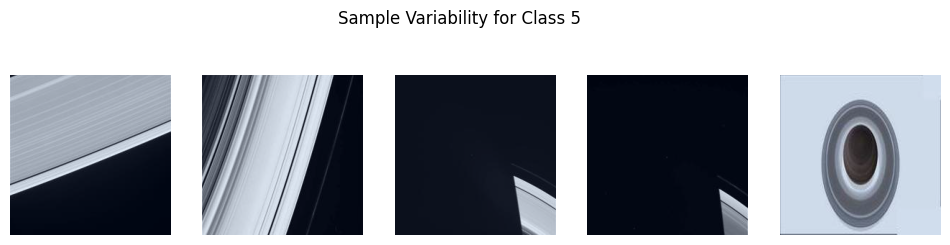

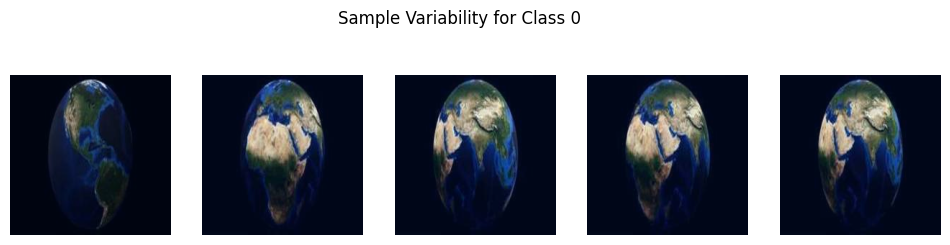

In [12]:
def show_class_variation(dataset, target_label, n=5):
    imgs = []
    for img, label in dataset:
        if int(label) == target_label:
            imgs.append(img)
        if len(imgs) == n:
            break

    plt.figure(figsize=(12,3))
    for i, img in enumerate(imgs):
        img_disp = img.permute(1,2,0).numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())
        plt.subplot(1,n,i+1)
        plt.imshow(img_disp)
        plt.axis("off")
    plt.suptitle(f"Sample Variability for Class {target_label}")
    plt.show()

show_class_variation(train_ds, target_label=5)  # Saturn
show_class_variation(train_ds, target_label=0)


Visual inspection reveals substantial intra-class variation in scale, lighting, and background across planetary images, indicating the need for data augmentation to improve generalization.
From our visualization we get -
Scale variation: Some Saturn images are tight crops of the rings, others show more of the planet. The apparent size of the subject changes a lot.

Lighting/contrast: Some are high-contrast grayscale ring shots, others are darker, low-contrast images with lots of black background.

Background variation: You’ve got pure black space, noisy space, and even what looks like a studio-style isolated Saturn render. That’s not a controlled dataset.


Possible augmentations for better generalizatio -
1. horizantal flip
2. smll angular rotations
3. random resized crops to better handle closeups etc


In [13]:
train_files = set([f for f, _ in train_ds.samples])
test_files  = set([f for f, _ in test_ds.samples])

overlap = train_files.intersection(test_files)
print("Overlap between train and test:", len(overlap))


Overlap between train and test: 0


No direct filename overlap was observed between training and test sets. Meaning no dublicates are observed across the sets.

## Conclusion from our EDA phase
This concludes our EDA we got pretty valauble insights sbout datasets from this like significant class imbalance was observed, with certain planetary classes being overrepresented. Raw images exhibited substantial variation in resolution, scale, lighting, and background composition. Visual inspection confirmed correct label assignments while also highlighting notable intra-class variability. These observations motivated the use of standardized resizing, normalization, and targeted data augmentation to improve model robustness and generalization.  So robust preprocessing is required


## Preprocessing


In [41]:
import torchvision.transforms as T

transform_train = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(10),
    T.RandomResizedCrop(224, scale=(0.9, 1.0)),

    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    T.ToTensor(),

    T.Normalize(
        mean=[0.2318, 0.2214, 0.2253],
        std=[0.3026, 0.2886, 0.2894]
    )
])

transform_val = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.2318, 0.2214, 0.2253],
        std=[0.3026, 0.2886, 0.2894]
    )
])
train_ds.transform = transform_train
test_ds.transform = transform_val
val_ds.transform = transform_val

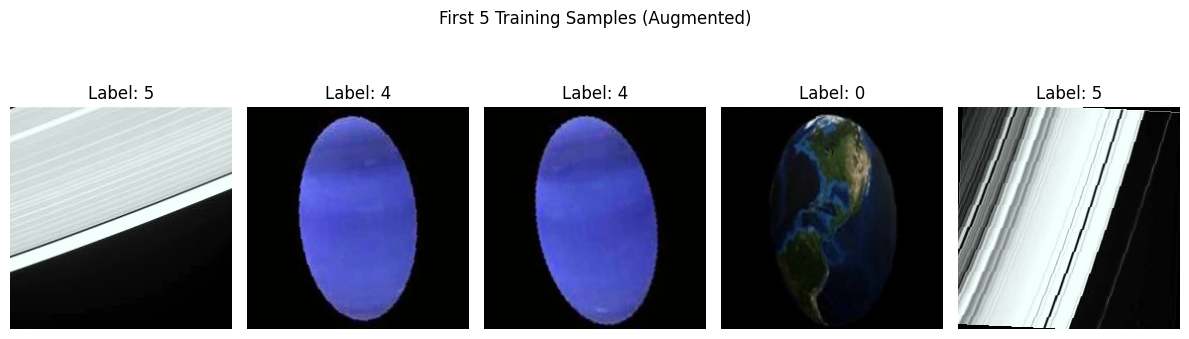

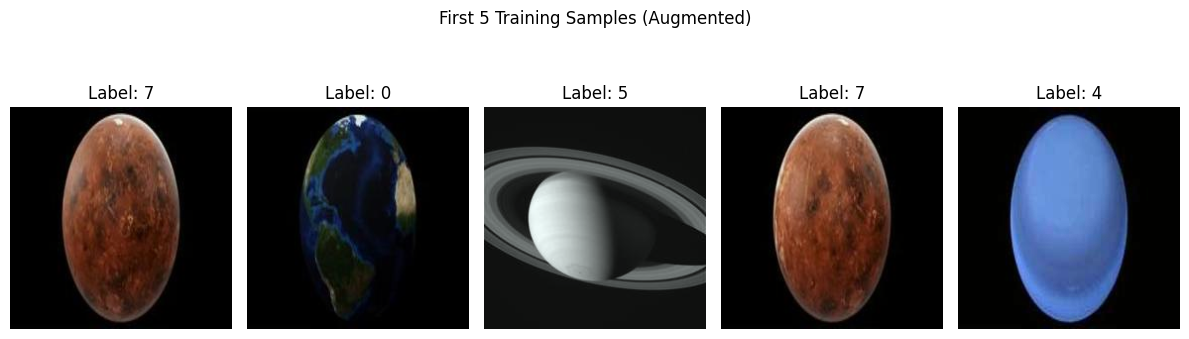

In [42]:


def show_first_n(dataset, title, n=5):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        img, label = dataset[i]
        img_disp = img.permute(1, 2, 0).numpy()
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())  # for display

        plt.subplot(1, n, i+1)
        plt.imshow(img_disp)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
show_first_n(train_ds, title="First 5 Training Samples (Augmented)", n=5)
show_first_n(val_ds, title="First 5 Training Samples (Augmented)", n=5)


## Actual Model


# CNN Model Architecture – What It Is and Why I Built It This Way

The model used in this project is a custom CNN inspired by the general design philosophy of ResNet. The core idea behind the architecture is to go slightly deeper than a basic “toy CNN” while still keeping the model small enough to train reasonably fast on a laptop GPU. Instead of stacking plain convolution layers and hoping gradients don’t die somewhere in the middle, the network uses residual connections so that deeper layers can learn refinements on top of earlier features rather than having to relearn everything from scratch.

At a high level, the model consists of:

An initial convolutional stem that extracts low-level features such as edges, simple textures, and color gradients from the input image.

A sequence of residual blocks that progressively increase the channel depth (e.g., 32 → 64 → 128 → 256) while reducing spatial resolution. These layers are responsible for learning more abstract and class-specific features such as planetary banding (Jupiter), ring structures (Saturn), surface textures (Mars, Mercury), and overall color distributions (Neptune, Uranus).

A global average pooling layer that compresses the spatial feature maps into a compact representation, followed by a fully connected layer that maps the learned features to class logits.

The residual connections are the main reason this architecture is more stable than a plain deep CNN. Instead of forcing each block to learn a complete transformation, the skip connections allow the network to learn small residual updates. This makes optimization easier, helps gradients flow backward through the network, and reduces the chance that deeper layers just become useless. In practice, this means the model trains faster and is less sensitive to depth-related issues like vanishing gradients.

The motivation for choosing a ResNet-inspired architecture comes from prior experience. I previously worked on a Food-101 classification task as part of the SPIDERR ML induction process, along with a couple of personal computer vision projects. In those settings, ResNet-based models consistently performed well on visually complex datasets with high intra-class variation and subtle inter-class differences. Food-101, in particular, involves distinguishing between visually similar classes under varying lighting, backgrounds, and viewpoints, which is structurally similar to this planetary classification problem (e.g., Neptune vs Uranus, or different Saturn views). Based on that experience, a ResNet-style approach felt like a sensible design choice rather than starting from a shallow CNN that might underfit the data.

Overall, this architecture is a deliberate middle ground:

It is more expressive and stable than a very shallow CNN.

It is far lighter and easier to train than a full pretrained ResNet-50 or ResNet-101.

It borrows proven ideas (residual learning, hierarchical feature extraction, global average pooling) from architectures that are known to work well on image classification problems.

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # the ResNet magic
        out = F.relu(out)
        return out


class PlanetResNetLike(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


## Model Architecture (What the CNN Is Actually Doing)

The model is just a stack of conv layers that slowly go from looking at pixels to recognizing planet-ish patterns.
At the start, it only understands super low-level stuff like edges, color gradients, and rough outlines. So basically it figures out where the planet is and what the background looks like.
As the layers go deeper, the network starts picking up more meaningful patterns. This is where it learns things like Jupiter’s bands, Saturn’s rings, Mars’ surface texture, and the general color/texture differences between planets. The spatial size of the feature maps goes down, but the number of channels goes up, so the model is trading raw detail for more abstract understanding.The residual connections are there so the network doesn’t choke as it gets deeper. Instead of every block having to relearn everything from scratch, it can just learn “small changes” on top of the previous features. This makes training less unstable and helps the deeper layers actually do something useful instead of becoming dead weight.

Near the end, the model uses global average pooling instead of flattening everything into a massive vector. This basically compresses each feature map into one number, which keeps the parameter count sane and reduces overfitting. It also makes the model focus more on whether a feature exists rather than exactly where it shows up.Finally, a simple fully connected layer takes these high-level features and turns them into class scores. At this point, the network isn’t thinking in terms of pixels anymore. It’s making decisions based on learned patterns like texture, structure, and overall appearance that separate one planet from another.

## Training

In [44]:
import torch

print(torch.cuda.get_device_name(0))



Tesla T4


In [45]:
from torch.utils.data import DataLoader

batch_size = 64
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,        # shuffle training data so model doesn’t memorize order
    num_workers=4,       # parallel data loading (set 0 if Windows throws issues)
    pin_memory=True,   # faster transfer to GPU

)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,       # don’t shuffle validation
    num_workers=2,
    pin_memory=True,

)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,       # don’t shuffle test, we want stable evaluation
    num_workers=2,
    pin_memory=True
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [46]:
import torch
print("Default device:", torch._C._get_default_device())

Default device: cpu


In [47]:
import torch
from torch.utils.data import DataLoader, TensorDataset

x = torch.randn(100, 3)
y = torch.randint(0, 2, (100,))

dataset = TensorDataset(x, y)

loader = DataLoader(dataset, batch_size=16, shuffle=False)

for batch in loader:
    break

print("DataLoader works")

DataLoader works


In [48]:
import time
start = time.time()
for i, (imgs, labels) in enumerate(train_loader):
    if i == 50:
        break
print("Loading 50 batches took:", time.time() - start, "seconds")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loading 50 batches took: 7.503025770187378 seconds


In [49]:

from torch.optim import Adam

device = torch.device("cuda")

model = PlanetResNetLike(num_classes=8).to(device)


# class-weighted loss because Saturn is hogging the dataset
from collections import Counter
train_labels = [int(label) for _, label in train_ds]
counts = Counter(train_labels)
total = sum(counts.values())
weights = torch.tensor([total / counts[i] for i in range(8)], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = Adam(model.parameters(), lr=1e-3)


In [51]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [52]:
@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [53]:
import time
x = torch.randn(64, 3, 224, 224, device=device)

start = time.time()
for _ in range(100):
    y = model(x)
    loss = y.mean()
    loss.backward()
    optimizer.zero_grad()

print("100 forward+backward passes took:", time.time() - start, "seconds")


100 forward+backward passes took: 13.34462285041809 seconds


In [55]:
num_epochs = 20 # increase to probably get better resultsz

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.3f}")


Epoch 01/20 | Train Loss: 0.5775, Train Acc: 0.811 | Val Loss: 0.8342, Val Acc: 0.620
Epoch 02/20 | Train Loss: 0.3729, Train Acc: 0.868 | Val Loss: 0.3687, Val Acc: 0.952
Epoch 03/20 | Train Loss: 0.2759, Train Acc: 0.903 | Val Loss: 0.5188, Val Acc: 0.850
Epoch 04/20 | Train Loss: 0.2394, Train Acc: 0.931 | Val Loss: 0.3176, Val Acc: 0.890
Epoch 05/20 | Train Loss: 0.2102, Train Acc: 0.939 | Val Loss: 0.3696, Val Acc: 0.841
Epoch 06/20 | Train Loss: 0.1690, Train Acc: 0.947 | Val Loss: 0.2618, Val Acc: 0.975
Epoch 07/20 | Train Loss: 0.1634, Train Acc: 0.951 | Val Loss: 0.2795, Val Acc: 0.924
Epoch 08/20 | Train Loss: 0.1623, Train Acc: 0.955 | Val Loss: 0.3078, Val Acc: 0.977
Epoch 09/20 | Train Loss: 0.1018, Train Acc: 0.978 | Val Loss: 0.2023, Val Acc: 0.949
Epoch 10/20 | Train Loss: 0.1125, Train Acc: 0.969 | Val Loss: 0.2092, Val Acc: 0.955
Epoch 11/20 | Train Loss: 0.1113, Train Acc: 0.974 | Val Loss: 0.2675, Val Acc: 0.958
Epoch 12/20 | Train Loss: 0.1321, Train Acc: 0.967 | V

## Analytcs

In [56]:
import torch
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


## Confusion matrix


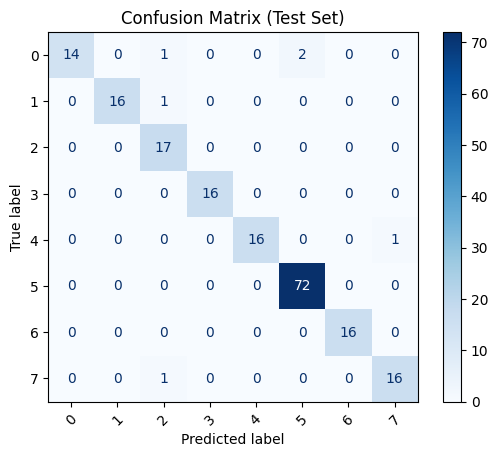

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [39]:
from sklearn.metrics import classification_report, precision_recall_fscore_support
class_names = ["Earth", "Jupiter", "Mars", "Mercury", "Neptune", "Saturn", "Uranus", "Venus"]
print(classification_report(all_labels, all_preds, target_names=class_names))

prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro")
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted")

print(f"Macro Precision:  {prec_macro:.3f}")
print(f"Macro Recall:     {rec_macro:.3f}")
print(f"Macro F1-score:   {f1_macro:.3f}")

print(f"Weighted Precision: {prec_weighted:.3f}")
print(f"Weighted Recall:    {rec_weighted:.3f}")
print(f"Weighted F1-score:  {f1_weighted:.3f}")


              precision    recall  f1-score   support

       Earth       0.85      1.00      0.92        17
     Jupiter       0.94      0.94      0.94        17
        Mars       1.00      0.94      0.97        17
     Mercury       0.94      1.00      0.97        16
     Neptune       1.00      0.94      0.97        17
      Saturn       1.00      0.92      0.96        72
      Uranus       0.84      1.00      0.91        16
       Venus       0.89      0.94      0.91        17

    accuracy                           0.95       189
   macro avg       0.93      0.96      0.94       189
weighted avg       0.95      0.95      0.95       189

Macro Precision:  0.933
Macro Recall:     0.960
Macro F1-score:   0.944
Weighted Precision: 0.953
Weighted Recall:    0.947
Weighted F1-score:  0.948
